In [14]:
import numpy as np
from skimage import io, img_as_float, transform, filters, feature, exposure, color, util
import time
import matplotlib.pyplot as plt



def split_bgr_stack(im):
    h = im.shape[0] // 3
    b = im[:h]
    g = im[h:2*h]
    r = im[2*h:3*h]
    return b, g, r

def crop_center(img, frac=0.9):
    """Return a centered crop to downweight borders during metric eval."""
    h, w = img.shape[:2]
    ch = int(h*frac)
    cw = int(w*frac)
    y0 = (h - ch)//2
    x0 = (w - cw)//2
    return img[y0:y0+ch, x0:x0+cw]

def to_edges(im):
    """Edge/structure emphasis to be robust to illumination changes."""
    if im.ndim == 3:
        im = color.rgb2gray(im)
    # Slight blur then Sobel
    return filters.sobel(filters.gaussian(im, sigma=1.0))

def ssd(a, b):
    d = a - b
    return np.sum(d*d)

def roll2(img, dy, dx):
    return np.roll(np.roll(img, dy, axis=0), dx, axis=1)

def brute_align(tgt, ref, search_radius=15, use_edges=True):
    """Align tgt to ref by searching integer translations in [-r, r]."""
    if use_edges:
        tgt_m = to_edges(tgt)
        ref_m = to_edges(ref)
    else:
        tgt_m = tgt
        ref_m = ref
    # Ignore borders: compare only center crop
    ref_c = crop_center(ref_m, 0.85)
    best = (0, 0)
    best_score = np.inf
    for dy in range(-search_radius, search_radius+1):
        for dx in range(-search_radius, search_radius+1):
            shifted = roll2(tgt_m, dy, dx)
            sc = ssd(crop_center(shifted, 0.85), ref_c)
            if sc < best_score:
                best_score = sc
                best = (dy, dx)
    return best


def pyramid_align(tgt, ref, levels=5, base_search=15):
    """Coarse-to-fine image pyramid alignment. Returns (dy, dx)."""
    # Build pyramids
    pyr_t = [tgt]
    pyr_r = [ref]
    for _ in range(1, levels):
        pyr_t.append(transform.rescale(pyr_t[-1], 0.5, anti_aliasing=True, channel_axis=None))
        pyr_r.append(transform.rescale(pyr_r[-1], 0.5, anti_aliasing=True, channel_axis=None))

    dy, dx = 0, 0
    tik = time.time()
    for lvl in reversed(range(levels)):
        t = pyr_t[lvl]
        r = pyr_r[lvl]
        # Upscale current estimate
        if lvl != levels-1:
            dy *= 2
            dx *= 2
        # Refine around current estimate
        r_pad = min(base_search, 12)  # local search window per level
        best = (0, 0)
        best_sc = np.inf

        # Pre-shift the target by current estimate to reduce search window
        t_est = roll2(t, dy, dx)
        # Use edges for metric robustness
        t_m = to_edges(t_est)
        r_m = to_edges(r)
        r_c = crop_center(r_m, 0.85)
        for ddy in range(-r_pad, r_pad+1):
            for ddx in range(-r_pad, r_pad+1):
                t_try = roll2(t_m, ddy, ddx)
                sc = ssd(crop_center(t_try, 0.85), r_c)
                if sc < best_sc:
                    best_sc = sc
                    best = (ddy, ddx)
        dy += best[0]
        dx += best[1]
        tok = time.time()
        # print(f"Level {lvl}: Best shift: {best}, Score: {best_sc:.4f}, Time: {tok - tik:.4f} s")
        # print("\n")
    return dy, dx

def align_pair(tgt, ref):
    """Dispatch to brute or pyramid based on size."""
    h, w = ref.shape[:2]
    if max(h, w) <= 100:  # small images: exhaustive is fine
        return brute_align(tgt, ref, search_radius=20)
    # large images: pyramid
    return pyramid_align(tgt, ref, levels=6, base_search=15)

# def auto_crop(rgb, valve=0.15):
#     """Remove uniform borders using edge density."""
#     g = to_edges(color.rgb2gray(rgb))
#     rows = g.mean(axis=1)
#     cols = g.mean(axis=0)
#     # Thresholds with small margin
#     r_th = valve * rows.max()
#     c_th = valve * cols.max()

#     top = np.argmax(rows > r_th)
#     bottom = len(rows) - np.argmax(rows[::-1] > r_th)
#     left = np.argmax(cols > c_th)
#     right = len(cols) - np.argmax(cols[::-1] > c_th)

#     # Guard rails
#     pad = 5
#     top = max(top - pad, 0)
#     left = max(left - pad, 0)
#     bottom = min(bottom + pad, rgb.shape[0])
#     right = min(right + pad, rgb.shape[1])

#     if bottom - top < 50 or right - left < 50:
#         return rgb  # avoid pathological crops
#     return rgb[top:bottom, left:right]
def auto_crop(rgb, edge_weight=0.5, edge_frac=0.25, pad=4, extra=12):
    edges = filters.sobel(filters.gaussian(color.rgb2gray(rgb), sigma=1.0))
    edges /= (edges.max() + 1e-6)

    R, G, B = rgb[..., 0], rgb[..., 1], rgb[..., 2]
    chroma = np.abs(R - G) + np.abs(G - B)
    chroma = filters.gaussian(chroma, sigma=1.0)
    chroma /= (chroma.max() + 1e-6)

    rows_score = edge_weight * edges.mean(axis=1) + (1 - edge_weight) * (1 - chroma.mean(axis=1))
    cols_score = edge_weight * edges.mean(axis=0) + (1 - edge_weight) * (1 - chroma.mean(axis=0))

    r_th = edge_frac * rows_score.max()
    c_th = edge_frac * cols_score.max()
    top    = int(np.argmax(rows_score > r_th))
    bottom = int(len(rows_score) - np.argmax(rows_score[::-1] > r_th))
    left   = int(np.argmax(cols_score > c_th))
    right  = int(len(cols_score) - np.argmax(cols_score[::-1] > c_th))

    top = max(top - pad, 0); left = max(left - pad, 0)
    bottom = min(bottom + pad, rgb.shape[0]); right = min(right + pad, rgb.shape[1])
    top += extra; left += extra; bottom -= extra; right -= extra

    if bottom - top < 50 or right - left < 50:
        return rgb
    return rgb[top:bottom, left:right]


def gray_world_white_balance(img):
    """Scale channels so their means match (gray-world)."""
    eps = 1e-6
    means = img.reshape(-1, 3).mean(axis=0) + eps
    scale = means.mean() / means
    balanced = img * scale
    return np.clip(balanced, 0, 1)

def postprocess(img):
    """Contrast stretch per-channel + white balance."""
    # Contrast stretch
    out = np.empty_like(img)
    for c in range(3):
        p1, p99 = np.percentile(img[..., c], (1, 99))
        out[..., c] = exposure.rescale_intensity(img[..., c], in_range=(p1, p99))
    # Gray-world WB
    out = gray_world_white_balance(out)
    return np.clip(out, 0, 1)


def final_crop(rgb, margin=20):
    out = rgb
    if 'auto_crop' in globals():
        try:
            out = auto_crop(out)
        except Exception:
            pass

    h, w = out.shape[:2]
    m = int(margin)
    m = max(0, min(m, min(h//4, w//4)))
    return out[m:h-m, m:w-m]

def aggressive_auto_crop(rgb, edge_frac=0.25, pad=3):
    g = filters.sobel(filters.gaussian(color.rgb2gray(rgb), sigma=1.0))
    rows = g.mean(axis=1)
    cols = g.mean(axis=0)

    r_th = float(edge_frac) * rows.max()
    c_th = float(edge_frac) * cols.max()

    top = np.argmax(rows > r_th)
    bottom = len(rows) - np.argmax(rows[::-1] > r_th)
    left = np.argmax(cols > c_th)
    right = len(cols) - np.argmax(cols[::-1] > c_th)

    top = max(int(top) - pad, 0)
    left = max(int(left) - pad, 0)
    bottom = min(int(bottom) + pad, rgb.shape[0])
    right = min(int(right) + pad, rgb.shape[1])

    if bottom - top < 50 or right - left < 50:
        return rgb
    return rgb[top:bottom, left:right]

def compare_crop(rgb, margin=20, use_aggressive=False, edge_frac=0.25, pad=3, figsize=(10,5), suptitle=None):
    if use_aggressive:
        cropped = aggressive_auto_crop(rgb, edge_frac=edge_frac, pad=pad)
    else:
        cropped = final_crop(rgb, margin=margin)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(rgb);      axes[0].set_title(f'Before\n{rgb.shape[1]}×{rgb.shape[0]}');   axes[0].axis('off')
    axes[1].imshow(cropped);  axes[1].set_title(f'After\n{cropped.shape[1]}×{cropped.shape[0]}'); axes[1].axis('off')
    if suptitle:
        fig.suptitle(suptitle)
    plt.show()
    return cropped


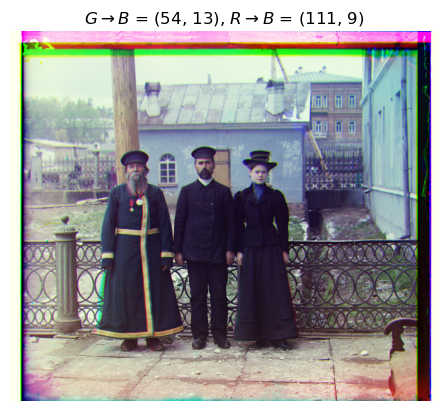

In [37]:
for filename in ["church","harvesters","icon","italil","lastochikino","lugano","melons","self_portrait","siren","three_generations"]:
    filetype = "tif"

    im = io.imread(f"{filename}.{filetype}")
    im = img_as_float(im)

    b, g, r = split_bgr_stack(im)
    H, W = b.shape[:2]

    def canon_shift(d, n):
        d = int(round(d))
        return ((d + n // 2) % n) - n // 2

    dy_g, dx_g = align_pair(g, b)
    dy_r, dx_r = align_pair(r, b)

    dy_g, dx_g = map(int, (dy_g, dx_g))
    dy_r, dx_r = map(int, (dy_r, dx_r))

    g_aligned = roll2(g, dy_g, dx_g)
    r_aligned = roll2(r, dy_r, dx_r)

    rgb = np.dstack([r_aligned, g_aligned, b])

    rgb = auto_crop(rgb)

    # print(rgb.shape)

    rgb = postprocess(rgb)


    plt.imshow(rgb)
    plt.axis('off')
    plt.title(rf"$G\rightarrow B$ = ({canon_shift(dy_g, H)}, {canon_shift(dx_g, W)}), $R\rightarrow B$ = ({canon_shift(dy_r, H)}, {canon_shift(dx_r, W)})")
    # plt.show()
    plt.savefig(f"{filename}_processed.jpg", bbox_inches='tight', pad_inches=0, dpi=300)
